# Modelo Red Neuronal con datos de viajes por minuto entre estaciones

Igual que el 7_6 pero eliminando la categoria 1 de la predicción

In [394]:
version = "7_9"

In [395]:
import pickle
import pandas as pd
import numpy as np
import json

pd.set_option("display.max_rows", None)   # Muestra todas las filas
pd.set_option("display.max_columns", None)  # Muestra todas las columnas
pd.set_option("display.width", None)     # No corta la tabla en varias líneas
pd.set_option("display.max_colwidth", None)  # Muestra el contenido de celdas completo

In [396]:
with open("../../data/normalized/df_normalized_dayOfYear.pk1", "rb") as f:
    df_data = pickle.load(f)

In [397]:
# Se redonde al minuto mas cercano
df_data["started_minute"] = df_data["started_at"].dt.round("min")

In [398]:
df_agg = df_data.groupby([
    "start_station_idx",
    "end_station_idx",
    "started_minute"
]).agg(
    n_viajes=("ride_id", "count"),
    year=("year", "first"),
    temp_std=("temp_std", "first"),
    wind_std=("wind_std", "first"),
    rel_humidity_std=("rel_humidity_std", "first"),
    precipitation_std=("precipitation_std", "first"),
    snow_depth_std=("snow_depth_std", "first"),
    hour_sin=("hour_sin", "first"),
    hour_cos=("hour_cos", "first"),
    month_sin=("month_sin", "first"),
    month_cos=("month_cos", "first"),
    event=("event", "any"),  # True si al menos un dato es true
    normal_day=("day_type_Normal", "any"),  # True si al menos un dato es true
    weekend_day=("day_type_Weekend", "any"),  # True si al menos un dato es true
    holiday_day=("day_type_Holiday", "any"),  # True si al menos un dato es true
    doy_sin=("doy_sin", "first"),
    doy_cos=("doy_cos", "first"),
    #member_casual=("member_casual_bool", "any"),  # True si al menos un dato es true
    #classic_bike=("rideable_type_classic_bike", "any"),  # True si al menos un dato es true
    #docked_bike=("rideable_type_docked_bike", "any"),  # True si al menos un dato es true
    #electric_bike=("rideable_type_electric_bike", "any"),  # True si al menos un dato es true
    #duration_min_mean=("duration_min", "mean"),
).reset_index()

In [399]:
df_agg.shape

(9073410, 20)

In [400]:
df_agg.describe()

,start_station_idx,end_station_idx,started_minute,n_viajes,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos,doy_sin,doy_cos
count,9.073410e+06,9.073410e+06,9073410,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06
mean,1.451035e+03,1.451958e+03,2023-03-15 06:23:51.479779072,1.048204e+00,2.022696e+03,-1.495024e-02,-1.812192e-03,8.774936e-03,4.883809e-05,1.967412e-03,-3.315338e-01,-2.758742e-01,5.239540e-02,-2.769533e-01,-2.239218e-02,-2.820444e-01
min,0.000000e+00,0.000000e+00,2022-01-01 00:00:00,1.000000e+00,2.022000e+03,-4.191219e+00,-1.996051e+00,-2.519273e+00,-9.970427e-02,-5.614845e-02,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-9.999907e-01,-9.999630e-01
25%,1.358000e+03,1.358000e+03,2022-08-06 17:06:00,1.000000e+00,2.022000e+03,-7.493464e-01,-6.917960e-01,-7.628922e-01,-9.970427e-02,-5.614845e-02,-9.362641e-01,-8.029042e-01,-5.000000e-01,-8.660254e-01,-7.638886e-01,-8.475409e-01
50%,1.447000e+03,1.448000e+03,2023-04-13 19:23:00,1.000000e+00,2.023000e+03,1.895027e-01,-8.000990e-02,1.485145e-02,-9.970427e-02,-5.614845e-02,-6.025698e-01,-3.916012e-01,1.224647e-16,-5.000000e-01,-2.581844e-02,-4.749511e-01
75%,1.565000e+03,1.565000e+03,2023-09-10 20:57:00,1.000000e+00,2.023000e+03,7.707278e-01,6.198615e-01,7.945084e-01,-9.970427e-02,-5.614845e-02,2.005080e-01,1.192704e-01,8.660254e-01,6.123234e-17,6.994583e-01,2.261157e-01
max,1.911000e+03,1.911000e+03,2024-06-01 00:00:00,9.000000e+00,2.024000e+03,2.175728e+00,5.576328e+00,2.359562e+00,6.945283e+01,7.287764e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,9.999907e-01,1.000000e+00
std,2.191965e+02,2.176947e+02,NaN,2.348621e-01,6.859159e-01,1.003718e+00,1.000607e+00,9.993908e-01,9.976954e-01,1.017557e+00,6.781692e-01,5.950339e-01,7.215361e-01,6.324060e-01,7.207822e-01,6.327896e-01


In [401]:
df_agg.iloc[10000:10010]

,start_station_idx,end_station_idx,started_minute,n_viajes,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos,event,normal_day,weekend_day,holiday_day,doy_sin,doy_cos
10000,5,1362,2022-06-21 00:57:00,1,2022,1.595537,0.115036,-1.872588,-0.099704,-0.056148,0.246788,0.969070,5.000000e-01,-8.660254e-01,False,True,False,False,0.179767,-0.983709
10001,5,1362,2022-06-30 23:12:00,1,2022,1.607251,1.549199,-1.694654,-0.099704,-0.056148,-0.208836,0.977951,5.000000e-01,-8.660254e-01,False,True,False,False,0.025818,-0.999667
10002,5,1362,2022-07-06 21:22:00,1,2022,0.976758,0.449277,0.293232,-0.099704,-0.056148,-0.636639,0.771162,1.224647e-16,-1.000000e+00,False,True,False,False,-0.077386,-0.997001
10003,5,1362,2022-07-10 10:15:00,1,2022,0.056858,-1.307653,1.096805,-0.099704,-0.056148,0.442419,-0.896808,1.224647e-16,-1.000000e+00,True,False,True,False,-0.145799,-0.989314
10004,5,1362,2022-07-14 18:18:00,1,2022,1.028438,-0.764584,-0.615571,-0.099704,-0.056148,-0.996974,0.077734,1.224647e-16,-1.000000e+00,False,True,False,False,-0.213521,-0.976938
10005,5,1362,2022-08-13 14:58:00,1,2022,0.801047,0.344502,-0.797331,-0.099704,-0.056148,-0.700857,-0.713301,-5.000000e-01,-8.660254e-01,False,False,True,False,-0.668064,-0.744104
10006,5,1362,2022-08-22 11:15:00,1,2022,0.212242,-0.741637,1.378055,-0.099704,-0.056148,0.196731,-0.980458,-5.000000e-01,-8.660254e-01,False,True,False,False,-0.774884,-0.632103
10007,5,1362,2022-09-03 13:02:00,1,2022,0.660994,-0.630728,0.861473,-0.099704,-0.056148,-0.266257,-0.963902,-8.660254e-01,-5.000000e-01,True,False,True,False,-0.888057,-0.459733
10008,5,1362,2022-09-20 17:01:00,1,2022,1.279257,0.561730,-0.131514,-0.099704,-0.056148,-0.966768,-0.255657,-8.660254e-01,-5.000000e-01,False,True,False,False,-0.982927,-0.183998
10009,5,1362,2022-10-04 08:27:00,1,2022,-0.664936,-1.996051,0.989662,-0.099704,-0.056148,0.800339,-0.599548,-1.000000e+00,-1.836970e-16,False,True,False,False,-0.998435,0.055917


In [402]:
df_agg['n_viajes'].value_counts(normalize=False)

n_viajes
1    8671457
2     372173
3      24990
4       4098
5        565
6        103
7         19
8          4
9          1
Name: count, dtype: int64

Claramente hay un desajuste de datos

# Se agrupan ciertos viajes

In [403]:
df_travel_witOut_1 = df_agg[df_agg['n_viajes'] != 1]
print(df_travel_witOut_1['n_viajes'].value_counts())

n_viajes
2    372173
3     24990
4      4098
5       565
6       103
7        19
8         4
9         1
Name: count, dtype: int64


In [404]:
df_travel_witOut_1 = df_travel_witOut_1.copy()
df_travel_witOut_1['n_viajes_agg'] = df_travel_witOut_1['n_viajes']
df_travel_witOut_1.loc[df_travel_witOut_1['n_viajes'] >= 5, 'n_viajes_agg'] = 5

# Revisar conteo por subclase5
print(df_travel_witOut_1['n_viajes_agg'].value_counts())


n_viajes_agg
2    372173
3     24990
4      4098
5       692
Name: count, dtype: int64


## Se divide la cantidad de viajes exceptuando la clase 1 (1 viaje)

In [405]:
# df_class = df_agg[df_agg['n_viajes'] != 1]
# print(df_class['n_viajes'].value_counts())

Se realiza una conversión de n_viajes a clases

In [406]:
# df_class.loc[:, "subclass"] = df_class["n_viajes"] - 1
# print(df_class['subclass'].value_counts())

Se agrupan los viajes 8, 9 y 7 en una sola clase

In [407]:
# mask = df_class['subclass'] >= 3
# df_class.loc[mask, 'subclass'] = 3

# # Revisar conteo por subclase
# print(df_class['subclass'].value_counts())

In [408]:
# # convertir a entero
# df_class['subclass'] = df_class['subclass'].astype(int)

## Simulación de datos con SMOT de las clases minoritarias

Se intenta no igualar las clases porque no tendria sentido en clases tan desvalanceadas por eso se limita el SMOTE

In [409]:
df_travel_witOut_1.dtypes

start_station_idx             int64
end_station_idx               int64
started_minute       datetime64[ns]
n_viajes                      int64
year                          int64
temp_std                    float64
wind_std                    float64
rel_humidity_std            float64
precipitation_std           float64
snow_depth_std              float64
hour_sin                    float64
hour_cos                    float64
month_sin                   float64
month_cos                   float64
event                          bool
normal_day                     bool
weekend_day                    bool
holiday_day                    bool
doy_sin                     float64
doy_cos                     float64
n_viajes_agg                  int64
dtype: object

In [410]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from collections import Counter

# --- 1. Separar features y target ---
df = df_travel_witOut_1.copy()

data_raw = df.drop(columns=['started_minute'])  # quitar datetime
y = df['n_viajes_agg'].astype(int)

print("Antes:", Counter(y))

# --- 3. Ajustar estrategia SMOTE ---
# Como tus clases 7 y 8 tienen muy pocos ejemplos,
# usamos k_neighbors=2 y fijamos targets razonables.

target_sizes = {
    4: 20_000,
    5: 10_000
}

sm = SMOTE(
    sampling_strategy=target_sizes,
    k_neighbors=2,
    random_state=42
)

# --- 4. Aplicar SMOTE ---
data_smote, y_smote = sm.fit_resample(data_raw, y)

print("Después:", Counter(y_smote))

# 4. Reconstruir DataFrame final
df_smote = pd.DataFrame(data_smote, columns=df_agg.columns.drop("started_minute"))
df_smote['n_viajes_agg'] = y_smote


Antes: Counter({2: 372173, 3: 24990, 4: 4098, 5: 692})
Después: Counter({2: 372173, 3: 24990, 4: 20000, 5: 10000})


In [411]:
df_smote.dtypes

start_station_idx      int64
end_station_idx        int64
n_viajes               int64
year                   int64
temp_std             float64
wind_std             float64
rel_humidity_std     float64
precipitation_std    float64
snow_depth_std       float64
hour_sin             float64
hour_cos             float64
month_sin            float64
month_cos            float64
event                   bool
normal_day              bool
weekend_day             bool
holiday_day             bool
doy_sin              float64
doy_cos              float64
n_viajes_agg           int64
dtype: object

## Obtención de datos

In [412]:
x_context = df_smote.drop(columns=[
    "n_viajes",
    #"started_minute",
    "start_station_idx",
    "end_station_idx",
    "n_viajes_agg"
])

x_start = df_smote[[
    "start_station_idx",
]]

x_end = df_smote[[
    "end_station_idx",
]]

y = df_smote["n_viajes_agg"]

In [413]:
x_context.shape

(427163, 16)

In [414]:
x_start.shape

(427163, 1)

In [415]:
x_end.shape

(427163, 1)

In [416]:
y.shape

(427163,)

## Compruebo que de verdad hay viajes de ida y vuelta con el mismo id

In [417]:
df_check = df_data["start_station_idx"] == df_data["end_station_idx"]

In [418]:
# Contar numero de True
n_same_station = df_check.sum()
print(f"Número de viajes de ida y vuelta con la misma estación de inicio y fin: {n_same_station}")

Número de viajes de ida y vuelta con la misma estación de inicio y fin: 615646


## Se continua diviendo los datos

In [419]:
with open("../../data/normalized/le_station_encoder.pkl", "rb") as f:
    le_station = pickle.load(f)
    
len(le_station.classes_)

1912

In [420]:
y.head()

0    2
1    2
2    2
3    2
4    2
Name: n_viajes_agg, dtype: int64

In [421]:
# El target empieza en 1 → lo pasamos a 0
# y_cls = y - 1

# num_classes = y_cls.max() + 1
# print("Clases totales:", num_classes)

In [422]:
x_context.dtypes

year                   int64
temp_std             float64
wind_std             float64
rel_humidity_std     float64
precipitation_std    float64
snow_depth_std       float64
hour_sin             float64
hour_cos             float64
month_sin            float64
month_cos            float64
event                   bool
normal_day              bool
weekend_day             bool
holiday_day             bool
doy_sin              float64
doy_cos              float64
dtype: object

In [423]:
from sklearn.model_selection import train_test_split

x_ctx_train, x_ctx_test, x_start_train, x_start_test, x_end_train, x_end_test, y_train, y_test = \
    train_test_split(x_context, x_start, x_end, y, test_size=0.2, random_state=42, stratify=y)

x_ctx_train, x_ctx_val, x_start_train, x_start_val, x_end_train, x_end_val, y_train, y_val = \
    train_test_split(x_ctx_train, x_start_train, x_end_train, y_train, test_size=0.2, random_state=42, stratify=y_train)


## Se calcula class_weight para evitar colpaso por dominación de la clase 1

In [424]:
y_train.head()

113157    2
25212     2
84760     2
378706    2
82315     2
Name: n_viajes_agg, dtype: int64

In [425]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes_present = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_present,
    y=y_train
)

class_weights = {i: w for i, w in zip(classes_present, class_weights)}
print(class_weights)


{np.int64(2): np.float64(0.2869389982786851), np.int64(3): np.float64(4.273227460297612), np.int64(4): np.float64(5.33953125), np.int64(5): np.float64(10.6790625)}


In [426]:
# print("Clases en train:", np.unique(y_train))
# print("Clases totales:", np.arange(num_classes))


## Se continua con la creación del modelo

### Se aumenta la normalización porque se ha observado que puede haber overfitting

In [427]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers
from tensorflow.keras.optimizers import Adam

num_stations = len(le_station.classes_)
num_features = x_context.shape[1]

l2_reg = 1e-4
drop_rate = 0.3

# Inputs
input_start = Input(shape=(1,), name='start_station')
input_end = Input(shape=(1,), name='end_station')
input_context = Input(shape=(num_features,), name='context')

# Embeddings
embed_dim = int(np.ceil(np.sqrt(num_stations)))
embed_start = layers.Embedding(num_stations, embed_dim)(input_start)
embed_end = layers.Embedding(num_stations, embed_dim)(input_end)

# Flatten embeddings
flat_start = layers.Flatten()(embed_start)
flat_end = layers.Flatten()(embed_end)

print(f"Num stations: {num_stations}")
print(f"Num features: {num_features}")
print(f"Embeddings dimension: { embed_dim}")

# Concatenar todo
x = layers.Concatenate()([flat_start, flat_end, input_context])
x = layers.Dense(128, kernel_regularizer=regularizers.l2(l2_reg))(x)
x = layers.LeakyReLU()(x)
x = layers.Dropout(drop_rate)(x)

x = layers.Dense(64, kernel_regularizer=regularizers.l2(l2_reg))(x)
x = layers.LeakyReLU()(x)
x = layers.Dropout(drop_rate)(x)

x = layers.Dense(32,  kernel_regularizer=regularizers.l2(l2_reg))(x)
x = layers.LeakyReLU()(x)
x = layers.Dropout(drop_rate)(x)

output = layers.Dense(1, activation='linear')(x)

model = Model(inputs=[input_start, input_end, input_context], outputs=output)
optimizer = Adam(learning_rate=1e-4)  # o prueba 1e-4, 5e-4
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
model.summary()

Num stations: 1912
Num features: 16
Embeddings dimension: 44


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ start_station       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_station         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_20        │ (None, 1, 44)     │     84,128 │ start_station[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_21        │ (None, 1, 44)     │     84,128 │ end_station[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_20          │ (None, 44)        │          0 │ embedding_20[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_21          │ (None, 44)        │          0 │ embedding_21[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context             │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 104)       │          0 │ flatten_20[0][0], │
│ (Concatenate)       │                   │            │ flatten_21[0][0], │
│                     │                   │            │ context[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 128)       │     13,440 │ concatenate_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_24      │ (None, 128)       │          0 │ dense_40[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 128)       │          0 │ leaky_re_lu_24[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 64)        │      8,256 │ dropout_30[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_25      │ (None, 64)        │          0 │ dense_41[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_31          │ (None, 64)        │          0 │ leaky_re_lu_25[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 32)        │      2,080 │ dropout_31[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_26      │ (None, 32)        │          0 │ dense_42[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_32          │ (None, 32)        │          0 │ leaky_re_lu_26[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 192,065 (750.25 KB)

 Trainable params: 192,065 (750.25 KB)

 Non-trainable params: 0 (0.00 B)

In [428]:

type(x_start_train)

pandas.core.frame.DataFrame

In [429]:
%%time
# Entrenamiento
history = model.fit(
    {'start_station': x_start_train, 'end_station': x_end_train, 'context': x_ctx_train},
    y_train,
    validation_data=(
        {'start_station': x_start_val, 'end_station': x_end_val, 'context': x_ctx_val},
        y_val
    ),    
    batch_size=128,
    epochs=50,
    #class_weight=class_weights, # No usar al predecir numero de viajes
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)


Epoch 1/50
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 1876.4573 - mae: 28.9946 - val_loss: 9.0401 - val_mae: 2.9341
Epoch 2/50
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 172.5270 - mae: 10.1376 - val_loss: 3.8834 - val_mae: 1.8583
Epoch 3/50
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 45.5795 - mae: 5.2084 - val_loss: 2.0160 - val_mae: 1.2594
Epoch 4/50
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 11.5621 - mae: 2.6152 - val_loss: 1.1937 - val_mae: 0.8744
Epoch 5/50
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2.7735 - mae: 1.2688 - val_loss: 0.9129 - val_mae: 0.6965
Epoch 6/50
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.9188 - mae: 0.6862 - val_loss: 0.6715 - val_mae: 0.4970
Epoch 7/50
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.5935 - mae: 0.5015 - val_loss: 0.5048 - val_mae: 0.2929
Epoch 8/50
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.5075 - mae: 0.4394 - val_loss: 0.4086 - val_mae: 0.3296
Epoch 9/50
2136/2136 ━━━━━━━━━━

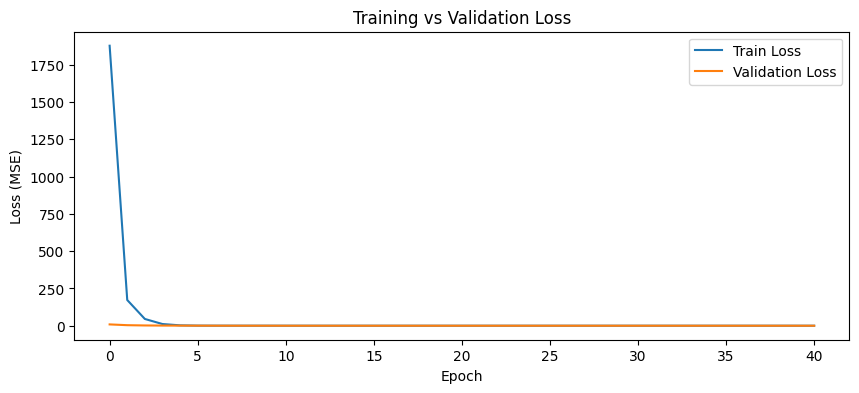

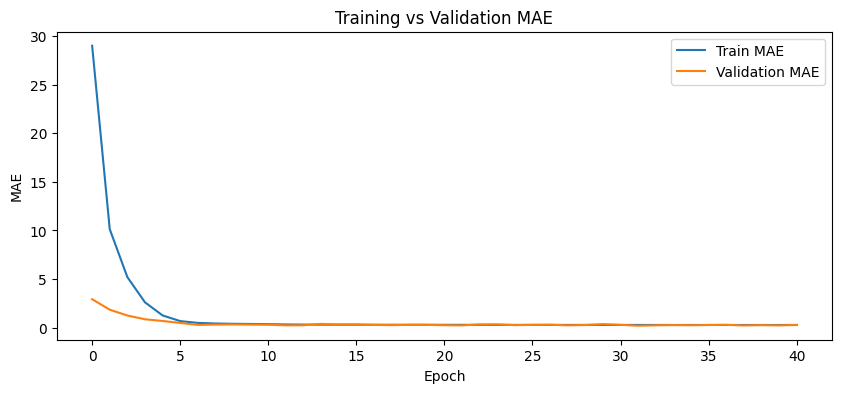

In [430]:
import matplotlib.pyplot as plt

# Pérdida (Loss)
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# MAE
plt.figure(figsize=(10,4))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.show()


In [ ]:
model.save(f"model_{version}_dayOfYear_month_correct.keras")

with open(f'history_{version}_dayOfYear_month_correct.json', 'w') as f:
    json.dump(history.history, f)

# Evaluar el modelo

In [432]:
# ---------- Evaluación final sobre el test set real
test_metrics = model.evaluate(
    {'start_station': x_start_test, 'end_station': x_end_test, 'context': x_ctx_test},
    y_test,
    verbose=2
)
print("Test metrics (loss, accuracy):", test_metrics)

2670/2670 - 2s - 775us/step - loss: 0.2553 - mae: 0.2847
Test metrics (loss, accuracy): [0.2553311586380005, 0.28471171855926514]


# Predicción del modelo

In [439]:
from tensorflow.keras.models import load_model

model = load_model("../../models/model_7_9/model_7_9_dayOfYear_month_correct.keras")

In [440]:
y_pred = model.predict({
    'start_station': x_start,
    'end_station': x_end,
    'context': x_context
})


13349/13349 ━━━━━━━━━━━━━━━━━━━━ 7s 545us/step


In [441]:
y_pred

array([[2.0413218],
       [2.0739467],
       [2.0533254],
       ...,
       [4.1720138],
       [2.2640576],
       [3.7973976]], shape=(427163, 1), dtype=float32)

In [442]:
import numpy as np

y_pred_int = np.rint(y_pred).astype(int)  # redondear al entero más cercano
y_pred_int = np.clip(y_pred_int, 2, 5)   # asegurar que esté entre 2 y 5


In [443]:
y_pred_int

array([[2],
       [2],
       [2],
       ...,
       [4],
       [2],
       [4]], shape=(427163, 1))

MAE: 0.1636, RMSE: 0.5246
Exact match accuracy: 88.30%


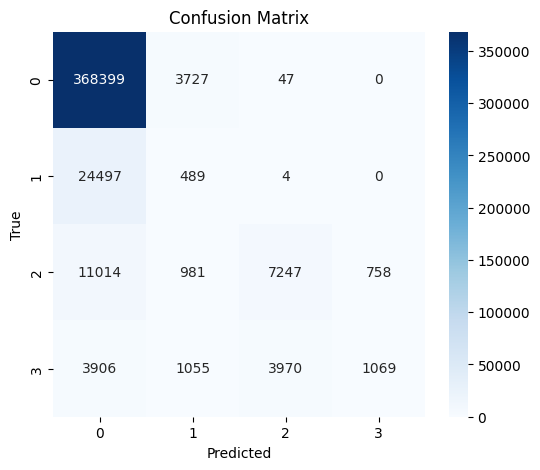

In [445]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

import matplotlib.pyplot as plt

mae = mean_absolute_error(y, y_pred_int)
mse = mean_squared_error(y, y_pred_int)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}")

# Exact match redondeado
acc = accuracy_score(y, y_pred_int)
print(f"Exact match accuracy: {acc*100:.2f}%")

# Matriz de confusión
cm = confusion_matrix(y, y_pred_int)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
